In [1]:

%pip install contractions
%pip install langdetect
%pip install spacy
%pip install nltk
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install wordcloud
%pip install enchant


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may ne

In [2]:

import pandas as pd
import re
import contractions
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
import nltk
from langdetect import detect
import enchant
from collections import Counter
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory


# 1) Load the Data

In [3]:
df = pd.read_csv('../customer_support_tickets_en.csv')
df['body'] = df['body'].fillna('')
print(f"Loaded {len(df)} rows")

Loaded 28261 rows


# 2) cleaning funtion

In [4]:

stats = {
    'literal_newlines_fixed': 0,
    'boilerplate_removed':    0,
    'contractions_expanded':  0,
    'hyphens_fixed':          0,
    'lowercased':             0,
    'html_tags_removed': 0,
    'special_chars_removed':  0,
    'whitespace_fixed':       0,
    'empty_after_clean':      0,
}

def clean_text(text):
    global stats
    text = str(text).strip()

    
    if '\\n' in text:
        text = text.replace('\\n', ' ')
        stats['literal_newlines_fixed'] += 1

   
    boilerplate_patterns = [
        r'^dear customer support team[,\s]*',
        r'^dear support team[,\s]*',
        r'^dear customer service[,\s]*',
        r'^hello[,\s]*',
        r'^hi[,\s]*',
        r'best regards.*$',
        r'kind regards.*$',
        r'sincerely.*$',
        r'thank you for your (help|assistance|support).*$',
    ]
    original = text
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.MULTILINE)
    if text != original:
        stats['boilerplate_removed'] += 1

   
    expanded = contractions.fix(text)
    if expanded != text:
        stats['contractions_expanded'] += 1
    text = expanded

  
    dehyphenated = re.sub(r'([a-zA-Z])-([a-zA-Z])', r'\1 \2', text)
    if dehyphenated != text:
        stats['hyphens_fixed'] += 1
    text = dehyphenated

   
    text = text.lower()
    stats['lowercased'] += 1

   
    html_tags_removed = re.sub(r'<.*?>', ' ', text)
    if html_tags_removed != text:
        stats['html_tags_removed'] += 1
    text = html_tags_removed

   
    cleaned = re.sub(r'[^a-z\s]', '', text)
    if cleaned != text:
        stats['special_chars_removed'] += 1
    text = cleaned

   
    stripped = re.sub(r'\s+', ' ', text).strip()
    if stripped != text:
        stats['whitespace_fixed'] += 1
    text = stripped

    if text == '':
        stats['empty_after_clean'] += 1

    return text

# 3) apply and print stats

In [5]:

df['clean_body'] = df['body'].apply(clean_text)


print("CLEANING STATISTICS")

for step, count in stats.items():
    pct = (count / len(df)) * 100
    print(f"  {step:<30} {count:>6}  ({pct:.1f}%)")



test_cases = df[df['body'].str.contains("http|@|<br>|n't|'ve|'ll", na=False)].head(5)

for i, row in test_cases.iterrows():
    print("ORIGINAL:", row['body'][:200])
    print("CLEANED: ", row['clean_body'][:200])
   

CLEANING STATISTICS
  literal_newlines_fixed            997  (3.5%)
  boilerplate_removed              4564  (16.1%)
  contractions_expanded            2885  (10.2%)
  hyphens_fixed                    3522  (12.5%)
  lowercased                      28261  (100.0%)
  html_tags_removed                 983  (3.5%)
  special_chars_removed           27513  (97.4%)
  whitespace_fixed                 5424  (19.2%)
  empty_after_clean                   1  (0.0%)
ORIGINAL: Dear Customer Support Team,\n\nI am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow. I've observed sporadic interruptions across severa
CLEANED:  i am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow i have observed sporadic interruptions across several devices which i believe may 
ORIGINAL: Customer Service Team,\n\nWe are facing concurrent failures in several office gadgets. The problem seems link

# 4) verfying each fix with examples

In [6]:


print("NEWLINE FIX")
sample = df[df['body'].str.contains(r'\\n', na=False)].iloc[0]
print("BEFORE:", sample['body'][:150])
print("AFTER: ", sample['clean_body'][:150])

print()

print("HYPHEN FIX ")
sample = df[df['body'].str.contains('cloud-native|real-time', na=False)].iloc[0]
print("BEFORE:", sample['body'][:150])
print("AFTER: ", sample['clean_body'][:150])

print()

print("CONTRACTION FIX")
sample = df[df['body'].str.contains("n't|'ve", na=False)].iloc[0]
print("BEFORE:", sample['body'][:150])
print("AFTER: ", sample['clean_body'][:150])

print()

print("BOILERPLATE REMOVAL")
sample = df[df['body'].str.startswith('Dear Customer Support Team', na=False)].iloc[0]
print("BEFORE:", sample['body'][:150])
print("AFTER: ", sample['clean_body'][:150])

print()

print("HTML TAGS REMOVAL")
sample = df[df['body'].str.contains('<br>|', na=False)].iloc[0]
print("BEFORE:", sample['body'][:150])
print("AFTER: ", sample['clean_body'][:150])

NEWLINE FIX
BEFORE: Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to
AFTER:  i am writing to report a significant problem with the centralized account management portal which currently appears to be offline this outage is block

HYPHEN FIX 
BEFORE: Dear Customer Support Team,\n\nI am reaching out to request comprehensive details on optimizing marketing workflows across multiple departments by uti
AFTER:  i am reaching out to request comprehensive details on optimizing marketing workflows across multiple departments by utilizing advanced analytics autom

CONTRACTION FIX
BEFORE: Dear Customer Support Team,\n\nI am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow. 
AFTER:  i am reaching out to report persistent issues with network connectivity that are significantly disrupting my workflow i have observed sporadic interru

BOI

# 5) Word count before vs after

In [7]:

df['wcbefore'] = df['body'].apply(lambda x: len(str(x).split()))
df['wcafter']  = df['clean_body'].apply(lambda x: len(x.split()))

print(f"Avg words BEFORE: {df['wcbefore'].mean():.1f}")
print(f"Avg words AFTER:  {df['wcafter'].mean():.1f}")
print(f"Avg words removed per ticket: {(df['wcbefore'] - df['wcafter']).mean():.1f}")

print(f"\nEmpty after cleaning:           {(df['clean_body'].str.strip() == '').sum()}")
print(f"Fewer than 3 words after clean: {(df['clean_body'].apply(lambda x: len(x.split()) < 3)).sum()}")

Avg words BEFORE: 55.4
Avg words AFTER:  54.8
Avg words removed per ticket: 0.6

Empty after cleaning:           1
Fewer than 3 words after clean: 54


# 6) saving cleaned data

In [8]:

df.to_csv('../customer_support_tickets_cleaned_final.csv', index=False)
print(f"Saved {len(df)} rows → customer_support_tickets_cleaned_final.csv")

Saved 28261 rows → customer_support_tickets_cleaned_final.csv


# 7) Language Filter

In [9]:

df = pd.read_csv('../customer_support_tickets_cleaned_final.csv')
df['clean_body'] = df['clean_body'].fillna('')
print(f'Loaded {len(df)} rows')
print(f'Before language filter: {len(df)} rows')
DetectorFactory.seed = 0
def is_english(text):
    try:
        return detect(str(text)) == "en"
    except:
        return False

df["is_en_text"] = df["clean_body"].apply(is_english)
df = df[df["is_en_text"]].copy()
df.drop(columns=["is_en_text"], inplace=True)
print(f'After language filter: {len(df)} rows')

Loaded 28261 rows
Before language filter: 28261 rows
After language filter: 28115 rows


# 8) Stop words

In [10]:
stop_words = set(ENGLISH_STOP_WORDS)

custom_stopwords = {
    'dear', 'customer', 'support', 'team',
    'hello', 'hi', 'thanks', 'thank',
    'regards', 'please', 'kindly',
    'hope', 'message'}

def tokenize_text(text):
    if text is None:
        return []
    tokens = text.split()
    tokens = [word for word in tokens
              if word not in stop_words
              and word not in custom_stopwords
              and len(word) >= 2]  
    return tokens

df['tokens'] = df['clean_body'].apply(tokenize_text)
df[['clean_body', 'tokens']].head()

,clean_body,tokens
0,i am writing to report a significant problem w...,"[writing, report, significant, problem, centra..."
1,i hope this message reaches you well i am reac...,"[reaches, reaching, request, detailed, informa..."
2,i hope this message finds you well i am reachi...,"[finds, reaching, request, clarification, bill..."
3,i hope this message reaches you well i am reac...,"[reaches, reaching, ask, compatibility, produc..."
4,dear customer support i hope this message reac...,"[reaches, good, health, eager, learn, features..."


# 9) Lemmatization

In [11]:
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    result = []
    for word in tokens:
        word = lemmatizer.lemmatize(word, 'v')
        word = lemmatizer.lemmatize(word, 'n')
        result.append(word)

    return result

df['processed_tokens'] = df['tokens'].apply(lemmatize_tokens)
df['processed_text'] = df['processed_tokens'].apply(lambda x: ' '.join(x))

df = df[df['processed_text'].str.strip() != ''].reset_index(drop=True)

df[['tokens', 'processed_tokens', 'processed_text']].head()

,tokens,processed_tokens,processed_text
0,"[writing, report, significant, problem, centra...","[write, report, significant, problem, centrali...",write report significant problem centralize ac...
1,"[reaches, reaching, request, detailed, informa...","[reach, reach, request, detail, information, c...",reach reach request detail information capabil...
2,"[finds, reaching, request, clarification, bill...","[find, reach, request, clarification, bill, pa...",find reach request clarification bill payment ...
3,"[reaches, reaching, ask, compatibility, produc...","[reach, reach, ask, compatibility, product, sp...",reach reach ask compatibility product specific...
4,"[reaches, good, health, eager, learn, features...","[reach, good, health, eager, learn, feature, p...",reach good health eager learn feature product ...


In [12]:
df['aftertandl'] = df['processed_text'].apply(lambda x: len(x.split()))
df[['wcafter','aftertandl']].head()

print(f'Average ticket length after processing:{df['aftertandl'].sum()/len(df):2f}')
print(f'Words removed during processing: {df['wcafter'].sum()-df['aftertandl'].sum()}')

Average ticket length after processing:29.158610
Words removed during processing: 727131


# 10) Save tokenized and lemmatized data

In [13]:

df.to_csv('../tokenized_and_lemmatized_tickets_final.csv', index=False)
print(f'Saved {len(df)} rows to tokenized_and_lemmatized_tickets_final.csv')

Saved 28113 rows to tokenized_and_lemmatized_tickets_final.csv


In [14]:
df = pd.read_csv('../tokenized_and_lemmatized_tickets_final.csv')
print(f'Loaded {len(df)} tickets.')
df.head()

Loaded 28113 tickets.


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,clean_body,wcbefore,wcafter,tokens,processed_tokens,processed_text,aftertandl
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,...,NaN,NaN,NaN,i am writing to report a significant problem w...,82,80,"['writing', 'report', 'significant', 'problem'...","['write', 'report', 'significant', 'problem', ...",write report significant problem centralize ac...,42
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,...,NaN,NaN,NaN,i hope this message reaches you well i am reac...,76,74,"['reaches', 'reaching', 'request', 'detailed',...","['reach', 'reach', 'request', 'detail', 'infor...",reach reach request detail information capabil...,40
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,...,NaN,NaN,NaN,i hope this message finds you well i am reachi...,91,81,"['finds', 'reaching', 'request', 'clarificatio...","['find', 'reach', 'request', 'clarification', ...",find reach request clarification bill payment ...,40
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,...,NaN,NaN,NaN,i hope this message reaches you well i am reac...,97,96,"['reaches', 'reaching', 'ask', 'compatibility'...","['reach', 'reach', 'ask', 'compatibility', 'pr...",reach reach ask compatibility product specific...,51
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,...,NaN,NaN,NaN,dear customer support i hope this message reac...,97,98,"['reaches', 'good', 'health', 'eager', 'learn'...","['reach', 'good', 'health', 'eager', 'learn', ...",reach good health eager learn feature product ...,41


# 11) Load processed text column to assess obvious issues which need handling.

In [15]:

pd.set_option('display.max_colwidth', None)
df['processed_text']

0                                                                                      write report significant problem centralize account management portal currently appear offline outage block access account setting lead substantial inconvenience attempt log multiple time use different browser device issue persist provide update outage status estimate time resolution alternative way access manage account downtime
1                                                                                         reach reach request detail information capability smart home integration product list website potential aim develop seamlessly interconnect home environment essential understand product interact various smart home platform provide detail compatibility information popular smart home ecosystem amazon alexa google assistant apple
2                                                                                                                  find reach request clarification bill payment p

In [16]:

DetectorFactory.seed = 0

def quick_lang_check(text):
    try:
        return detect(str(text))
    except:
        return "error"
    
sample = df['clean_body'].sample(min(500, len(df)), random_state=42)
langs = sample.apply(quick_lang_check)

print("Language distribution in sample:")
print(langs.value_counts())
print(f"\nNon-English percentage: {(langs != 'en').sum() / len(langs) * 100:.2f}%")

Language distribution in sample:
clean_body
en    500
Name: count, dtype: int64

Non-English percentage: 0.00%


# 12) Identify tickets which are too short after cleaning

In [17]:

short_tickets = df['processed_text'].apply(lambda x: len(x.split()) <= 3)
print(f'Number of processed tickets with 3 words or fewer: {short_tickets.sum()} ')
print(f'Tokens removed: {df.loc[short_tickets,'aftertandl'].sum()}')
pd.set_option('display.max_colwidth', 50)
df[short_tickets]

Number of processed tickets with 3 words or fewer: 194 
Tokens removed: 500


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_6,tag_7,tag_8,clean_body,wcbefore,wcafter,tokens,processed_tokens,processed_text,aftertandl
552,Protection of Medical Information,Requesting Assistance,To address concerns regarding the security of ...,Change,Product Support,high,en,52.0,Security,Privacy,...,NaN,NaN,NaN,requesting assistance,2,2,"['requesting', 'assistance']","['request', 'assistance']",request assistance,2
574,Incorporate NAS SaaS Solution,Can you offer comprehensive instructions?,Please facilitate a call at your convenience t...,Request,Customer Service,medium,en,52.0,Product,Feature,...,NaN,NaN,NaN,can you offer comprehensive instructions,5,5,"['offer', 'comprehensive', 'instructions']","['offer', 'comprehensive', 'instruction']",offer comprehensive instruction,3
999,Integration Assistance,Can you supply the integration instructions?,"<name>, thank you for contacting the service d...",Request,Customer Service,medium,en,52.0,Feature,Documentation,...,NaN,NaN,NaN,can you supply the integration instructions,6,6,"['supply', 'integration', 'instructions']","['supply', 'integration', 'instruction']",supply integration instruction,3
1179,Assistance with Digital Brand Expansion Tactics,Would you be able to share more information?,"<name>, thank you for your interest in digital...",Request,Customer Service,low,en,52.0,Strategy,Marketing,...,NaN,NaN,NaN,would you be able to share more information,8,8,"['able', 'share', 'information']","['able', 'share', 'information']",able share information,3
1270,Ensuring the Security of Hospital Systems,Requesting assistance,Help in effectively safeguarding hospital syst...,Request,Product Support,medium,en,52.0,Security,IT,...,NaN,NaN,NaN,requesting assistance,2,2,"['requesting', 'assistance']","['request', 'assistance']",request assistance,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26912,Incorrect invoice issued for this month,The invoice is found to be incorrect.,"Dear <name>,\nThank you for contacting us rega...",Incident,Billing and Payments,medium,en,NaN,Billing,Payment,...,NaN,NaN,NaN,the invoice is found to be incorrect,7,7,"['invoice', 'incorrect']","['invoice', 'incorrect']",invoice incorrect,2
27021,Project on Scalability Features,Request for detailed information,Will send a comprehensive email with informati...,Request,IT Support,medium,en,NaN,Feature,Documentation,...,NaN,NaN,NaN,request for detailed information,4,4,"['request', 'detailed', 'information']","['request', 'detail', 'information']",request detail information,3
27423,NaN,Seeking assistance with billing,Kindly provide your account number for billing...,Problem,Billing and Payments,medium,en,NaN,Billing,Payment,...,NaN,NaN,NaN,seeking assistance with billing,4,4,"['seeking', 'assistance', 'billing']","['seek', 'assistance', 'bill']",seek assistance bill,3
28000,Improved Security for Medical Information,Need Assistance,We can assist with enhancing the security of y...,Change,General Inquiry,medium,en,NaN,Security,IT,...,NaN,NaN,NaN,need assistance,2,2,"['need', 'assistance']","['need', 'assistance']",need assistance,2


# 13) Remove short tickets from dataset

In [18]:

df_filtered= df[~short_tickets].copy()
df = df_filtered.reset_index(drop=True)

print(f'Tickets of length <=3 have been removed: {len(df)} tickets remaining ')

Tickets of length <=3 have been removed: 27919 tickets remaining 


In [19]:
# Identify upper tickets length outliers
df['aftertandl'].describe()

count    27919.000000
mean        29.343315
std         14.557802
min          4.000000
25%         17.000000
50%         29.000000
75%         41.000000
max        143.000000
Name: aftertandl, dtype: float64

In [20]:
# Identify cutoff length
max_words = df['aftertandl'].quantile(0.99)
print(f'99th percentile word count of after preprocessing: {max_words}')

99th percentile word count of after preprocessing: 67.0


Number of tickets above 99th percentile:266
Proportion of tickets above 99th percentile:0.0095%


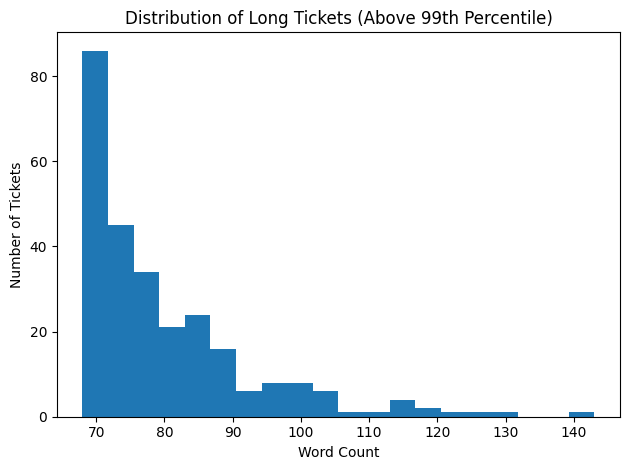

In [21]:
# Calculate proportion of tickets that exceed cutoff
above_cutoff = df[df['aftertandl'] > max_words]
print(f'Number of tickets above 99th percentile:{len(above_cutoff)}')
print(f'Proportion of tickets above 99th percentile:{len(above_cutoff)/len(df):.4f}%')

above_cutoff['aftertandl'].hist(bins=20)
plt.xlabel('Word Count')
plt.ylabel('Number of Tickets')
plt.title('Distribution of Long Tickets (Above 99th Percentile)')

plt.grid(False)
plt.tight_layout()
plt.show()

In [22]:
# Apply truncation
df['trunc_tokens'] = df['processed_text'].apply(lambda x: x.split()[:85])
df['trunc_processed_text'] = df['trunc_tokens'].apply(lambda x: ' '.join(x))

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,...,tag_8,clean_body,wcbefore,wcafter,tokens,processed_tokens,processed_text,aftertandl,trunc_tokens,trunc_processed_text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,...,NaN,i am writing to report a significant problem w...,82,80,"['writing', 'report', 'significant', 'problem'...","['write', 'report', 'significant', 'problem', ...",write report significant problem centralize ac...,42,"[write, report, significant, problem, centrali...",write report significant problem centralize ac...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,...,NaN,i hope this message reaches you well i am reac...,76,74,"['reaches', 'reaching', 'request', 'detailed',...","['reach', 'reach', 'request', 'detail', 'infor...",reach reach request detail information capabil...,40,"[reach, reach, request, detail, information, c...",reach reach request detail information capabil...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,...,NaN,i hope this message finds you well i am reachi...,91,81,"['finds', 'reaching', 'request', 'clarificatio...","['find', 'reach', 'request', 'clarification', ...",find reach request clarification bill payment ...,40,"[find, reach, request, clarification, bill, pa...",find reach request clarification bill payment ...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,...,NaN,i hope this message reaches you well i am reac...,97,96,"['reaches', 'reaching', 'ask', 'compatibility'...","['reach', 'reach', 'ask', 'compatibility', 'pr...",reach reach ask compatibility product specific...,51,"[reach, reach, ask, compatibility, product, sp...",reach reach ask compatibility product specific...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,...,NaN,dear customer support i hope this message reac...,97,98,"['reaches', 'good', 'health', 'eager', 'learn'...","['reach', 'good', 'health', 'eager', 'learn', ...",reach good health eager learn feature product ...,41,"[reach, good, health, eager, learn, feature, p...",reach good health eager learn feature product ...


In [23]:
# Calculate Average Ticket Length
df['word_count_final'] = df['trunc_processed_text'].apply(lambda x: len(x.split()))
avg_word_count= (df['word_count_final'].sum())/len(df)
print(f'After preprocessing average ticket length is {avg_word_count:.2f} words.')

After preprocessing average ticket length is 29.31 words.


# Save tokenized and lemmatized data

In [24]:

df.to_csv('../complete_preprocessing_final.csv', index=False)

In [25]:
# Check the output
import pandas as pd
df = pd.read_csv('../complete_preprocessing_final.csv')
print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"Avg words: {df['word_count_final'].mean():.2f}")

Rows: 27919
Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'clean_body', 'wcbefore', 'wcafter', 'tokens', 'processed_tokens', 'processed_text', 'aftertandl', 'trunc_tokens', 'trunc_processed_text', 'word_count_final']
Avg words: 29.31
